
# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Demo Notebook: Static vs. Interactive Visualization, Interaction Loops & Visual Thinking Design Patterns

We build one running dataset — a synthetic **country development dataset** (150 countries, years
2000–2020, indicators like GDP per capita, life expectancy, population and region) — in the style of
the Gapminder / OECD examples used in the slides. We reuse it across sections so you can see how the
*same data* looks and behaves under different interaction techniques.

> **How to use this notebook:** Run cells top to bottom. Cells using `ipywidgets` (sliders) and
> `plotly` (hover/zoom/box-select) only become interactive when you actually run them in a live
> Jupyter kernel — a static export will only show the last rendered frame.


In [ ]:

# If a package below is missing in your environment, uncomment the next line:
# %pip install -q plotly ipywidgets anywidget

# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import ipywidgets as widgets
from ipywidgets import interact, interactive, FloatRangeSlider, HBox, VBox

sns.set_theme(style="whitegrid")
np.random.seed(42)
print("Libraries loaded.")


Libraries loaded.



## 0. The Running Dataset

We synthesize a country-level development dataset, similar in spirit to the OECD dataset referenced
in the slides (Slide 24). It has enough structure (region, time, multiple numeric indicators) to
support every interaction technique we demo below: dynamic queries, brushing, table lens, network
zooming, and more.


In [ ]:

regions = ["Africa", "Asia", "Europe", "Americas", "Oceania"]
n_countries = 150
years = list(range(2000, 2021))

country_names = [f"Country_{i:03d}" for i in range(n_countries)]
country_region = {c: np.random.choice(regions, p=[0.28, 0.30, 0.20, 0.18, 0.04]) for c in country_names}

# Give every country a baseline + growth trend so the data tells a believable story over time
records = []
for c in country_names:
    region = country_region[c]
    base_gdp = np.random.lognormal(mean=8.5, sigma=1.1)           # starting GDP per capita (~USD)
    base_life = np.random.normal(60, 10)
    base_pop = np.random.lognormal(mean=15.5, sigma=1.3)
    gdp_growth = np.random.normal(0.025, 0.02)                     # ~2.5% average annual growth
    life_growth = np.random.normal(0.3, 0.15)                      # years of life expectancy gained/yr
    pop_growth = np.random.normal(0.012, 0.008)

    for i, y in enumerate(years):
        gdp = base_gdp * (1 + gdp_growth) ** i * np.random.normal(1, 0.03)
        life = np.clip(base_life + life_growth * i + np.random.normal(0, 1.5), 35, 90)
        pop = base_pop * (1 + pop_growth) ** i
        records.append((c, region, y, max(gdp, 200), life, pop))

df = pd.DataFrame(records, columns=["country", "region", "year", "gdp_per_capita", "life_expectancy", "population"])
df["gdp_per_capita"] = df["gdp_per_capita"].round(1)
df["life_expectancy"] = df["life_expectancy"].round(1)
df["population"] = df["population"].round(0).astype(int)

df_latest = df[df.year == 2020].reset_index(drop=True)
print(df.shape)
df.head()


(3150, 6)


,country,region,year,gdp_per_capita,life_expectancy,population
0,Country_000,Asia,2000,4071.9,61.7,5151893
1,Country_000,Asia,2001,4151.6,61.4,5244706
2,Country_000,Asia,2002,4060.7,67.2,5339192
3,Country_000,Asia,2003,3878.1,63.6,5435380
4,Country_000,Asia,2004,4015.4,64.1,5533301



## 1. Static vs. Interactive Visualizations  *(TB 2, Sec 9.4 — Slides 4–8)*

**What:** Static visualizations are pre-computed, fixed images. Interactive visualizations respond to
user input in real time, letting the *viewer* build their own view of the data.

**Why:** As dataset complexity grows past what a single static layout can resolve, static charts force
the author to pick one story; interactive charts let the analyst discover many.

**Demo:** Below, the *same* 2020 snapshot (GDP per capita vs. life expectancy) is rendered two ways.


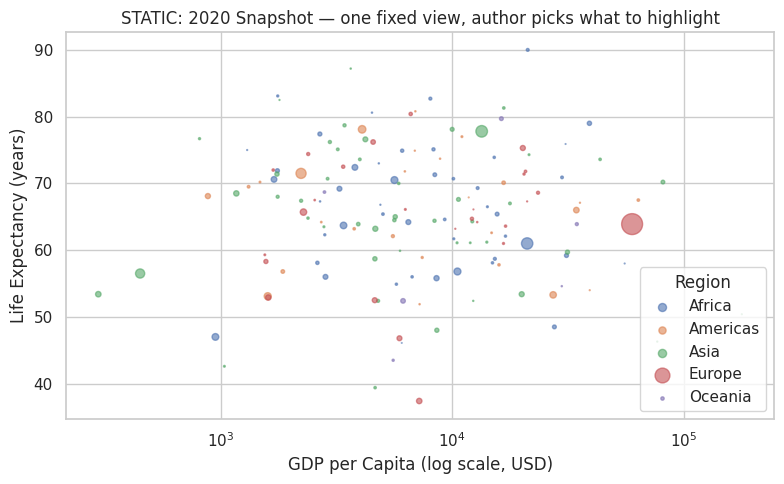

Static: the reader cannot ask 'which country is that dot?' or 'what about 2010?' — the
author already decided the story and the reader can only look, not query.


In [ ]:

# --- STATIC version: one fixed viewpoint, author-chosen annotations ---
fig, ax = plt.subplots(figsize=(8, 5))
for region, group in df_latest.groupby("region"):
    ax.scatter(group.gdp_per_capita, group.life_expectancy, s=group.population/2e6,
               alpha=0.6, label=region)
ax.set_xscale("log")
ax.set_xlabel("GDP per Capita (log scale, USD)")
ax.set_ylabel("Life Expectancy (years)")
ax.set_title("STATIC: 2020 Snapshot — one fixed view, author picks what to highlight")
ax.legend(title="Region", loc="lower right")
plt.tight_layout()
plt.show()
print("Static: the reader cannot ask 'which country is that dot?' or 'what about 2010?' — the")
print("author already decided the story and the reader can only look, not query.")


In [ ]:

# --- INTERACTIVE version: hover for identity, zoom, click-drag to pan, legend toggling ---
fig = px.scatter(
    df_latest, x="gdp_per_capita", y="life_expectancy",
    size="population", color="region", hover_name="country",
    log_x=True, size_max=45,
    title="INTERACTIVE: 2020 Snapshot — hover, zoom, and toggle regions live",
    labels={"gdp_per_capita": "GDP per Capita (USD, log scale)", "life_expectancy": "Life Expectancy (years)"}
)
fig.update_layout(height=500)
fig.show()
print("Interactive: hover reveals the country name, the legend can isolate a region by clicking it,")
print("and the scroll wheel / box-select can zoom into a crowded cluster — the viewer drives the story.")


Interactive: hover reveals the country name, the legend can isolate a region by clicking it,
and the scroll wheel / box-select can zoom into a crowded cluster — the viewer drives the story.



**Takeaway (Slides 5–8):** Neither is universally "better" — the choice depends on *target audience*,
*data-story complexity*, and *ROI* (engagement, content quality, update cost). Static builds are
roughly 5x cheaper; interactive builds measurably increase session time and unique visits (the deck's
Top Gear example: 15s static vs. 1m04s interactive).



## 2. Narrative Control and the Cognitive Thread  *(TB 2, Sec 9.4 — Slide 9)*

**What:** In *narrative* mode the author controls the sequence the viewer sees. In *exploratory* mode
the analyst's own search goals drive the sequence.

**Why:** Slide decks and reports are a **hybrid**: the structure is authored, but a reader can still
flip back and forth. Overloading a narrative presentation with too much interactivity breaks the
presenter's thread — the level of control should match the context.

**Demo:** A narrative sequence (fixed order of frames telling one story) vs. the same data left open
for exploration.


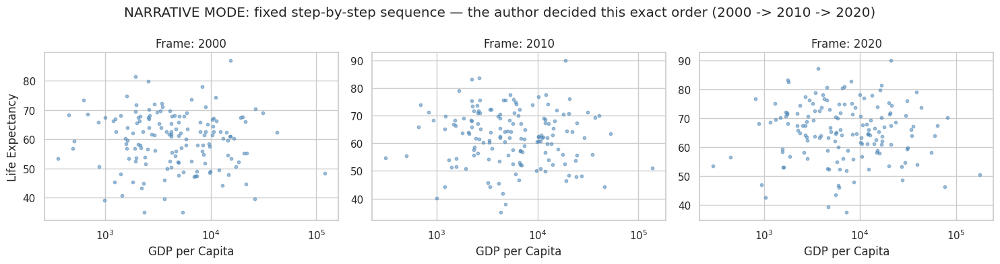

In [ ]:

# NARRATIVE: pre-ordered sequence of static frames, each building on the last (author-controlled)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
story_years = [2000, 2010, 2020]
for ax, y in zip(axes, story_years):
    snap = df[df.year == y]
    ax.scatter(snap.gdp_per_capita, snap.life_expectancy, s=10, alpha=0.5, c="steelblue")
    ax.set_xscale("log")
    ax.set_title(f"Frame: {y}")
    ax.set_xlabel("GDP per Capita")
    if ax is axes[0]:
        ax.set_ylabel("Life Expectancy")
fig.suptitle("NARRATIVE MODE: fixed step-by-step sequence — the author decided this exact order (2000 -> 2010 -> 2020)")
plt.tight_layout()
plt.show()


In [ ]:

# EXPLORATORY: an animated/scrubbable timeline — the viewer chooses which year to inspect and in what order
fig = px.scatter(
    df, x="gdp_per_capita", y="life_expectancy", animation_frame="year",
    color="region", size="population", size_max=40, hover_name="country",
    log_x=True, range_x=[df.gdp_per_capita.min(), df.gdp_per_capita.max()],
    range_y=[30, 95],
    title="EXPLORATORY MODE: drag the year slider yourself, in any order, at any pace"
)
fig.update_layout(height=500)
fig.show()



## 3. Limitations of Static Visuals & Epistemic Actions  *(TB 2, Sec 10.1 — Slides 10–11)*

**What:** An **epistemic action** is any interface manipulation (hover, zoom, select) done purely to
*uncover* information — it changes what the viewer *sees*, not the underlying data (unlike a
*pragmatic* action, which changes the data itself).

**Why:** Static graphics hit a physical wall with high-dimensional data — cramming everything into one
canvas creates clutter that forces expensive, exhaustive manual scanning.

**Demo:** Plot every country x every year at once (static clutter) vs. the same data made legible
through an epistemic action — hovering to query on demand.


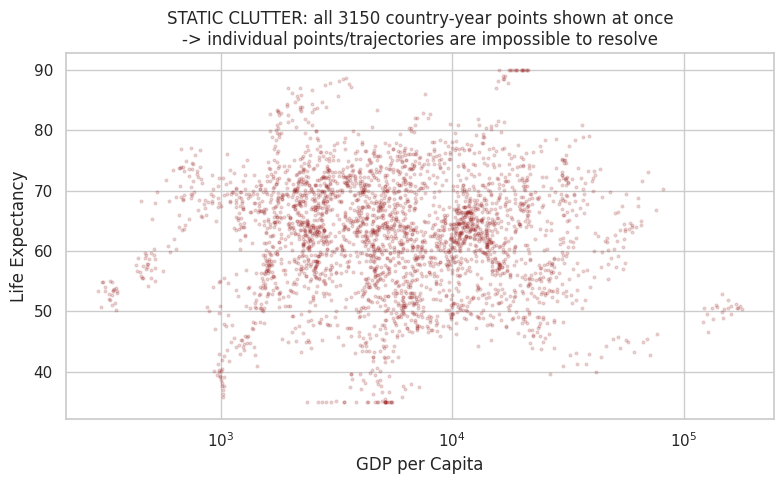

In [ ]:

# Static "all-at-once" clutter: every country-year point drawn simultaneously
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df.gdp_per_capita, df.life_expectancy, s=4, alpha=0.15, c="darkred")
ax.set_xscale("log")
ax.set_xlabel("GDP per Capita")
ax.set_ylabel("Life Expectancy")
ax.set_title(f"STATIC CLUTTER: all {len(df)} country-year points shown at once\n"
             "-> individual points/trajectories are impossible to resolve")
plt.tight_layout()
plt.show()


In [ ]:

# Epistemic action: hovering queries ONE trajectory on demand, instead of showing all 3150 points at once
fig = px.line(
    df.sort_values("year"), x="year", y="gdp_per_capita", color="country",
    hover_name="country",
    title="EPISTEMIC ACTION DEMO: 150 overlapping trajectories — hover over any line to query it"
)
fig.update_traces(line=dict(width=1), opacity=0.35, showlegend=False)
fig.update_layout(height=480, yaxis_type="log")
fig.show()
print("Every line is drawn, but the chart stays *usable* because hovering (an epistemic action) reveals")
print("one country's identity and exact values on demand -- nothing about the underlying data changes.")


Every line is drawn, but the chart stays *usable* because hovering (an epistemic action) reveals
one country's identity and exact values on demand -- nothing about the underlying data changes.



## 4. The Human–Computer Navigation Control Loop  *(TB 2, Sec 10.3 — Slide 12)*

**What:** Human interaction with a visualization is modeled as **three nested feedback loops**
operating at different timescales:

| Loop | Timescale | Job |
|---|---|---|
| Physical (eye-hand) | sub-second | tracking the cursor / gaze |
| Navigation | seconds | building a spatial "mental map" |
| Problem-solving | minutes+ | forming & testing hypotheses |

**Why:** A delay at *any* loop breaks the level above it — laggy cursor tracking (physical) disrupts
spatial navigation, which in turn disrupts the analytical task.

**Demo:** A schematic diagram of the three loops (this is a conceptual model, so the "demo" is a clear
visual of the hierarchy rather than a numeric simulation).


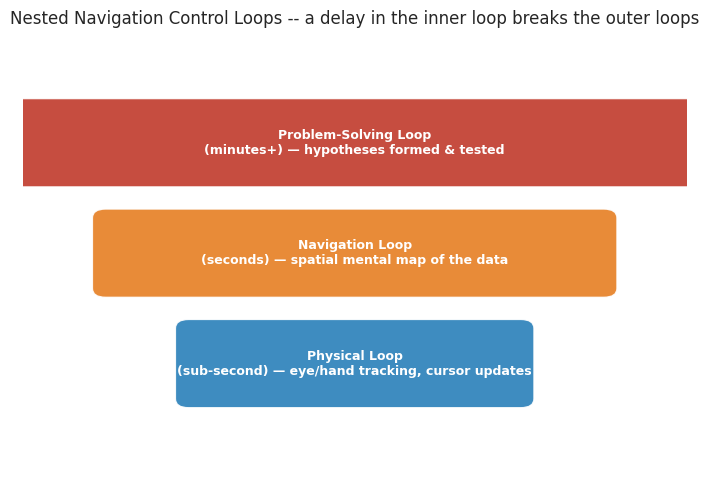

In [ ]:

fig, ax = plt.subplots(figsize=(7, 5))
loops = [
    ("Problem-Solving Loop\n(minutes+) — hypotheses formed & tested", 0.75, "#c0392b"),
    ("Navigation Loop\n(seconds) — spatial mental map of the data", 0.5, "#e67e22"),
    ("Physical Loop\n(sub-second) — eye/hand tracking, cursor updates", 0.25, "#2980b9"),
]
for label, y, color in loops:
    width = 1.0 - (0.75 - y)
    rect = mpatches.FancyBboxPatch((0.5 - width/2, y-0.08), width, 0.16,
                                    boxstyle="round,pad=0.02", fc=color, ec="white", alpha=0.9)
    ax.add_patch(rect)
    ax.text(0.5, y, label, ha="center", va="center", color="white", fontsize=9, weight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("Nested Navigation Control Loops -- a delay in the inner loop breaks the outer loops")
plt.tight_layout()
plt.show()



## 5. Fitts' Law  *(TB 2, Sec 10.2 — Slides 13–15)*

**What:** Fitts' Law predicts the time to move a cursor to a target:

$$ ID = \log_2\left(\frac{D}{W} + 1\right) \qquad\qquad MT = a + b \cdot ID $$

where **D** = distance to the target, **W** = target width, **ID** = index of difficulty (bits),
and **a, b** are empirical constants of the input device / user.

**Why:** It gives interface designers a rigorous way to reason about *how big* and *how close*
interactive targets (buttons, handles, nodes) need to be for fast, comfortable selection.

**Demo A — the exact worked example from Slide 14/15** (D=16cm, W=2cm, a=0.2s, b=0.1s/bit).


In [ ]:

def fitts_law(D, W, a=0.2, b=0.1):
    """Fitts' Law: returns (index_of_difficulty_bits, movement_time_seconds)."""
    ID = np.log2(D / W + 1)
    MT = a + b * ID
    return ID, MT

D, W, a, b = 16, 2, 0.2, 0.1
ID, MT = fitts_law(D, W, a, b)
print(f"Index of Difficulty (ID) = log2({D}/{W} + 1) = {ID:.2f} bits")
print(f"Movement Time (MT)       = {a} + {b} x {ID:.2f}   = {MT:.3f} seconds")
assert abs(MT - 0.517) < 0.005, "Should match the slide's worked answer of 0.517s"
print("Matches the slide's worked solution: MT = 0.517 seconds")


Index of Difficulty (ID) = log2(16/2 + 1) = 3.17 bits
Movement Time (MT)       = 0.2 + 0.1 x 3.17   = 0.517 seconds
Matches the slide's worked solution: MT = 0.517 seconds


**Demo B — why this matters for UI design:** sweep target width to see how MT explodes as buttons shrink, for several distances.

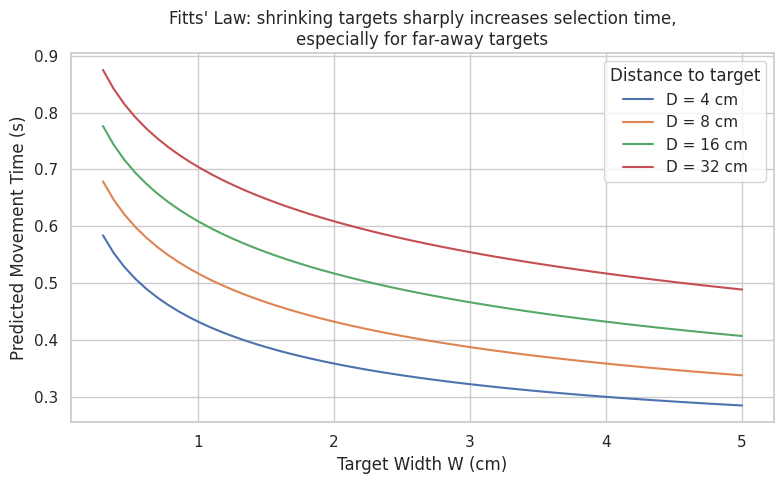

Design implication: place FREQUENT actions in LARGE, CLOSE targets (e.g. bottom corners of screen,
large toolbar icons) -- this is exactly why menu bars and the OS taskbar hug screen edges/corners.


In [ ]:

widths = np.linspace(0.3, 5, 60)
fig, ax = plt.subplots(figsize=(8, 5))
for D_val in [4, 8, 16, 32]:
    MTs = [fitts_law(D_val, w, a, b)[1] for w in widths]
    ax.plot(widths, MTs, label=f"D = {D_val} cm")
ax.set_xlabel("Target Width W (cm)")
ax.set_ylabel("Predicted Movement Time (s)")
ax.set_title("Fitts' Law: shrinking targets sharply increases selection time,\nespecially for far-away targets")
ax.legend(title="Distance to target")
plt.tight_layout()
plt.show()
print("Design implication: place FREQUENT actions in LARGE, CLOSE targets (e.g. bottom corners of screen,")
print("large toolbar icons) -- this is exactly why menu bars and the OS taskbar hug screen edges/corners.")



## 6. The Perceptual Penalty of Machine Lag  *(TB 2, Sec 10.2 — Slide 16)*

**What:** Machine lag is the delay between a physical action and its visual update. It effectively adds
to Fitts' Law's movement time, and the penalty is **non-linear** — worse for small/precise targets.

**Why:** Even sub-second lag causes overcorrection (the classic "cursor hunting" feeling), breaking
natural eye-hand coordination. Real-time interfaces should keep latency **under 100ms**.

**Demo:** We extend Fitts' Law with a lag penalty term and show how the *relative* slowdown grows as
targets shrink.


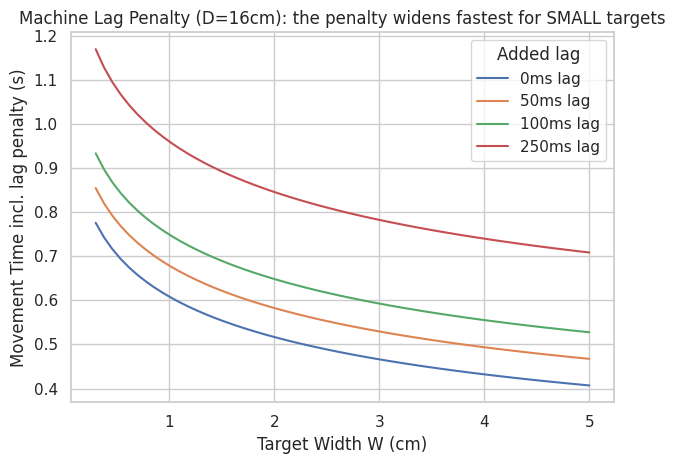

This is why the slide recommends keeping interactive latency below 100ms for analytical tasks --
beyond that threshold the penalty on small, precise targets grows sharply.


In [ ]:

def fitts_law_with_lag(D, W, lag_ms, a=0.2, b=0.1):
    """Adds machine lag as extra overhead applied once per corrective sub-movement.
    The smaller W is relative to D, the more corrective movements are typically needed."""
    ID, MT_ideal = fitts_law(D, W, a, b)
    # Approximate: lag penalty compounds with difficulty (more corrections needed for harder targets)
    correction_factor = 1 + (ID / 10)
    MT_with_lag = MT_ideal + (lag_ms / 1000) * correction_factor
    return MT_ideal, MT_with_lag

widths = np.linspace(0.3, 5, 60)
D_fixed = 16
for lag in [0, 50, 100, 250]:
    penalties = [fitts_law_with_lag(D_fixed, w, lag)[1] for w in widths]
    plt.plot(widths, penalties, label=f"{lag}ms lag")
plt.xlabel("Target Width W (cm)")
plt.ylabel("Movement Time incl. lag penalty (s)")
plt.title(f"Machine Lag Penalty (D={D_fixed}cm): the penalty widens fastest for SMALL targets")
plt.legend(title="Added lag")
plt.tight_layout()
plt.show()
print("This is why the slide recommends keeping interactive latency below 100ms for analytical tasks --")
print("beyond that threshold the penalty on small, precise targets grows sharply.")



## 7. The Drill-Down Epistemic Cost Hierarchy  *(TB 2, Sec 10.4 — Slide 17)*

**What:** Not all epistemic actions cost the same. From cheapest to most expensive:

`Eye Fixation (100-200ms) < Hover Query (~1s) < Click-to-Open Panel (~2s) < Window Replacement (heavy reset)`

**Why:** **Design rule** — always prefer the cheapest interaction pattern that still answers the
question, to preserve the analyst's short-term visual working memory.

**Demo:** A cost hierarchy chart, then a live example: hovering (cheap) vs. a full click-through
(expensive) on the same data.


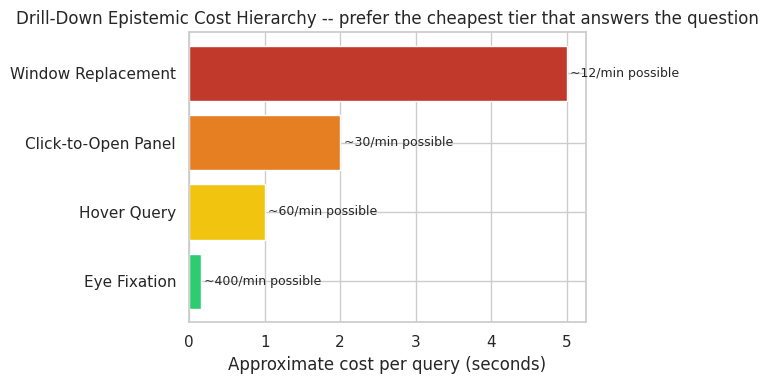

In [ ]:

costs = pd.DataFrame({
    "action": ["Eye Fixation", "Hover Query", "Click-to-Open Panel", "Window Replacement"],
    "approx_cost_seconds": [0.15, 1.0, 2.0, 5.0],
    "queries_per_min_possible": [400, 60, 30, 12],
})
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(costs.action, costs.approx_cost_seconds, color=["#2ecc71", "#f1c40f", "#e67e22", "#c0392b"])
ax.set_xlabel("Approximate cost per query (seconds)")
ax.set_title("Drill-Down Epistemic Cost Hierarchy -- prefer the cheapest tier that answers the question")
for bar, q in zip(bars, costs.queries_per_min_possible):
    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2, f"~{q}/min possible", va="center", fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:

# Live comparison: HOVER (cheap tier) reveals detail instantly without leaving context
fig = px.scatter(df_latest, x="gdp_per_capita", y="life_expectancy", color="region",
                  size="population", hover_name="country", log_x=True, size_max=40,
                  title="CHEAP TIER -- Hover Query: detail-on-demand, context never lost")
fig.update_layout(height=430)
fig.show()


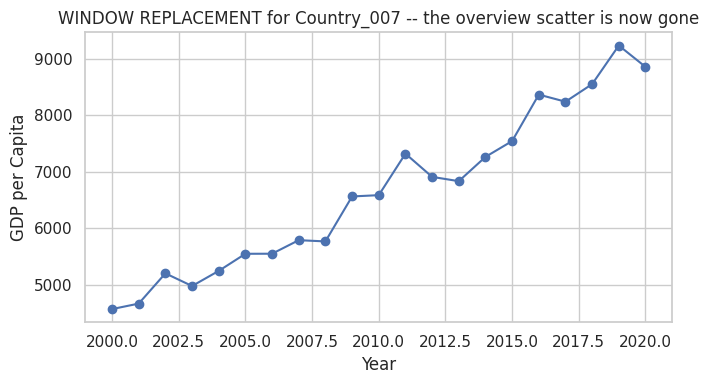

Notice: to see any OTHER country now, or to return to the overview, requires navigating back --
that's the 'heavy cognitive restart' the slide warns about.


In [ ]:

# EXPENSIVE TIER -- Window Replacement: drilling into one country replaces the whole view,
# forcing a full context reset to get back to the overview.
def drill_down_window(country_name):
    sub = df[df.country == country_name]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(sub.year, sub.gdp_per_capita, marker="o")
    ax.set_title(f"WINDOW REPLACEMENT for {country_name} -- the overview scatter is now gone")
    ax.set_xlabel("Year"); ax.set_ylabel("GDP per Capita")
    plt.tight_layout()
    plt.show()

drill_down_window("Country_007")
print("Notice: to see any OTHER country now, or to return to the overview, requires navigating back --")
print("that's the 'heavy cognitive restart' the slide warns about.")



## 8. The Focus-Context Problem  *(TB 2, Sec 10.3 — Slide 18)*

**What:** The mismatch between needing fine-grained detail (focus) and an overall structural view
(context) at the same time.

**Why:** Detail views that lose their surrounding context become uninterpretable. Three canonical
fixes: (1) multiple linked windows, (2) geometric distortion, (3) rapid zooming — all demoed below.


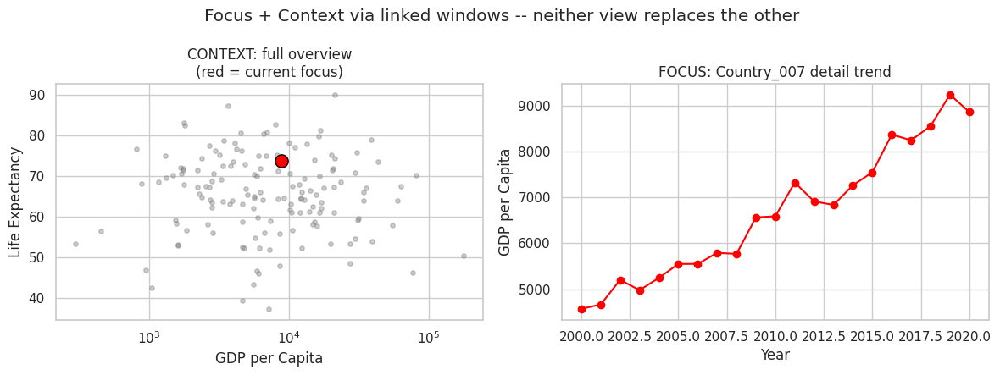

In [ ]:

# Fix #1: multiple linked windows -- overview (left) always visible alongside detail (right)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(df_latest.gdp_per_capita, df_latest.life_expectancy, s=15, alpha=0.4, c="gray")
focus = df_latest[df_latest.country == "Country_007"]
axes[0].scatter(focus.gdp_per_capita, focus.life_expectancy, s=120, c="red", edgecolor="black", zorder=5)
axes[0].set_xscale("log"); axes[0].set_title("CONTEXT: full overview\n(red = current focus)")
axes[0].set_xlabel("GDP per Capita"); axes[0].set_ylabel("Life Expectancy")

sub = df[df.country == "Country_007"]
axes[1].plot(sub.year, sub.gdp_per_capita, marker="o", color="red")
axes[1].set_title("FOCUS: Country_007 detail trend")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("GDP per Capita")
fig.suptitle("Focus + Context via linked windows -- neither view replaces the other")
plt.tight_layout()
plt.show()



## 9. Spatial Navigation Metaphors for 3D Interfaces  *(TB 2, Sec 10.2 — Slide 19)*

**What:** Familiar mental models for navigating 3D space: **World-in-Hand** (grab & rotate a compact
object), **Flying** (unconstrained movement through a large terrain), **Point-and-Go** (teleport-walk
to a clicked destination). Constraining unnecessary degrees of freedom (e.g. locking roll) reduces
navigation errors.

**Why:** Without a metaphor, users must consciously manage 6 degrees of freedom (x, y, z, pitch, yaw,
roll) — mapping to something familiar makes navigation intuitive.

**Demo:** A 3D scatter (GDP, life expectancy, population) you can rotate/drag — this *is* the
"World-in-Hand" metaphor: you're grabbing and turning a compact data object.


In [ ]:

fig = px.scatter_3d(
    df_latest, x="gdp_per_capita", y="life_expectancy", z="population",
    color="region", hover_name="country", log_x=True, log_z=True,
    title="World-in-Hand metaphor: drag to rotate the whole 'object', scroll to zoom"
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(height=550)
fig.show()
print("Try dragging: you are rotating the *entire dataset as one compact object*, like turning it in your")
print("hand -- this is efficient for localized inspection but wouldn't scale to 'flying' through a huge terrain.")


Try dragging: you are rotating the *entire dataset as one compact object*, like turning it in your
hand -- this is efficient for localized inspection but wouldn't scale to 'flying' through a huge terrain.



## 10. Spatial Distortion: Geometric Fisheye Views  *(TB 2, Sec 10.2 — Slide 20)*

**What:** Fisheye distortion expands screen space around a focal point while compressing everything
around it — giving detail AND context in a *single* undistorted-feeling view (up to a scale limit,
~5x, beyond which patterns stop being recognizable).

**Why:** It solves focus+context without needing separate windows — but at the cost of moving
landmarks, which can disorient the viewer.

**Demo:** We implement a simple 1-D fisheye transform on an evenly-spaced grid and show the distortion
around a chosen focal point.


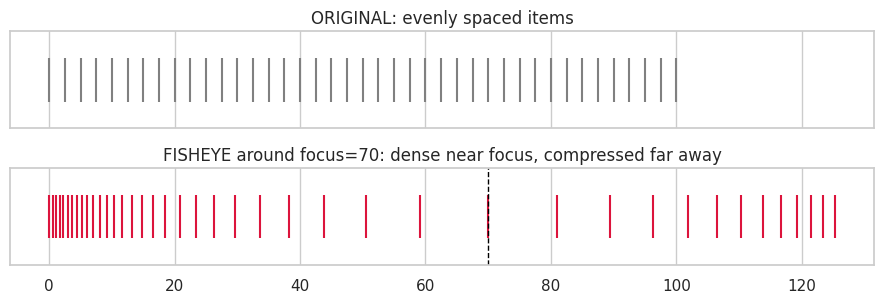

Notice items near the dashed focus line spread apart (magnified = easy to read), while distant
items compress together but remain visible (context preserved) -- exactly the focus+context trade.


In [ ]:

def fisheye_transform(positions, focus, distortion=4):
    """Sarkar & Brown-style fisheye: magnify near `focus`, compress far away."""
    positions = np.array(positions, dtype=float)
    d = positions - focus
    # normalized distortion function bounded so max scaling stays near `distortion`x
    sign = np.sign(d)
    magnitude = np.abs(d)
    transformed = sign * ((distortion + 1) * magnitude) / (distortion * magnitude / (magnitude.max()+1e-9) + 1)
    return focus + transformed

grid = np.linspace(0, 100, 41)
focus_point = 70
distorted = fisheye_transform(grid, focus_point, distortion=4)

fig, axes = plt.subplots(2, 1, figsize=(9, 3.2), sharex=True)
axes[0].eventplot([grid], colors="gray")
axes[0].set_yticks([]); axes[0].set_title("ORIGINAL: evenly spaced items")
axes[1].eventplot([distorted], colors="crimson")
axes[1].axvline(focus_point, color="black", ls="--", lw=1)
axes[1].set_yticks([]); axes[1].set_title(f"FISHEYE around focus={focus_point}: dense near focus, compressed far away")
plt.tight_layout()
plt.show()
print("Notice items near the dashed focus line spread apart (magnified = easy to read), while distant")
print("items compress together but remain visible (context preserved) -- exactly the focus+context trade.")



## 11. Rapid Zooming and Google-Earth-style Mechanics  *(TB 2, Sec 10.3 — Slide 21)*

**What:** Continuous, animated scale transitions on a single canvas (rather than distortion). Smooth
zoom (ideally <1s transitions, ~3-4x/sec magnification) preserves object identity across scale jumps.

**Why:** It avoids fisheye's landmark-shifting disorientation, but needs persistent grids/minimaps so
users don't get lost mid-zoom.

**Demo:** Plotly's native zoom/pan on a dense scatter — try scrolling to zoom into a cluster; axis
ticks (a persistent coordinate grid) keep you oriented exactly as the slide recommends.


In [ ]:

fig = px.scatter(df, x="gdp_per_capita", y="life_expectancy", color="region",
                  opacity=0.35, hover_name="country",
                  title="Rapid Zooming demo: scroll/box-select to zoom smoothly into any cluster; axes stay as landmarks")
fig.update_xaxes(type="log", showgrid=True)
fig.update_yaxes(showgrid=True)
fig.update_layout(height=500, dragmode="zoom")
fig.show()



## 12. Interactive Magic Lenses  *(TB 2, Sec 10.3 — Slide 22)*

**What:** A magic lens is a movable, coordinate-linked filter that reveals a *hidden data layer* only
inside a bounded region, overlaid on the base view.

**Why:** It lets users integrate an extra abstract variable with the underlying spatial layout, without
permanently changing the base chart or opening a separate window.

**Demo:** A base scatter (region colors) with a lens circle you can reposition — inside the lens, we
reveal a hidden attribute (population, encoded as point size) that's hidden everywhere else.


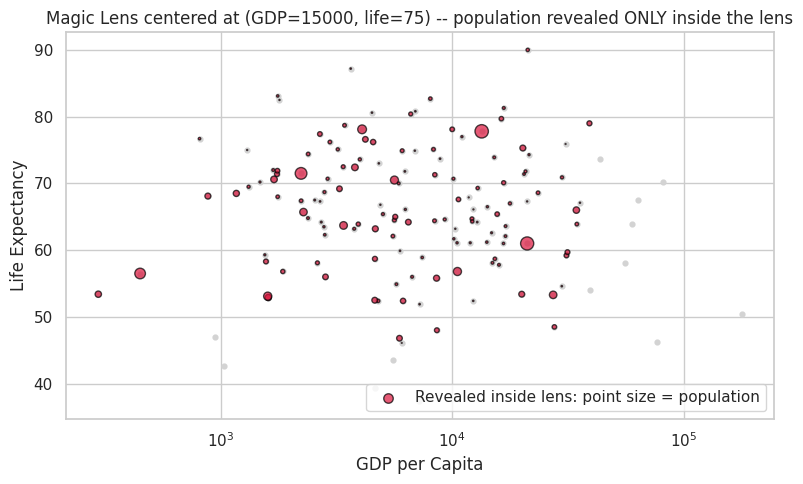

In [ ]:

def show_magic_lens(cx, cy, radius=25000):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(df_latest.gdp_per_capita, df_latest.life_expectancy, s=12, c="lightgray")

    dist = np.sqrt((df_latest.gdp_per_capita - cx)**2 + ((df_latest.life_expectancy - cy)*800)**2)
    inside = df_latest[dist < radius]
    ax.scatter(inside.gdp_per_capita, inside.life_expectancy,
               s=inside.population/1.5e6, c="crimson", alpha=0.7, edgecolor="black",
               label="Revealed inside lens: point size = population")

    lens = plt.Circle((cx, cy), radius/800, color="royalblue", fill=False, lw=2, ls="--")
    # matplotlib Circle needs matched data units; instead draw an ellipse-like patch via axvspan approximation
    ax.set_xscale("log")
    ax.set_xlabel("GDP per Capita"); ax.set_ylabel("Life Expectancy")
    ax.set_title(f"Magic Lens centered at (GDP={cx}, life={cy}) -- population revealed ONLY inside the lens")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

show_magic_lens(cx=15000, cy=75)



## 13. Interacting with Non-Spatial Data: Dynamic Queries  *(TB 2, Sec 10.4 — Slide 23)*

**What:** Real-time filtering of a multi-dimensional dataset using range sliders — the classic
"Aperture JS movie dashboard" pattern from the slide.

**Why:** Continuous slider drag lets target structures emerge from noise instantly, with response
times ideally under 100ms. Works well up to ~100,000 points with 5 or fewer sliders.

**Demo:** Two double-ended range sliders (`ipywidgets`) filtering GDP per capita and life expectancy
live.


In [ ]:

gdp_slider = FloatRangeSlider(value=[df_latest.gdp_per_capita.min(), df_latest.gdp_per_capita.max()],
                               min=df_latest.gdp_per_capita.min(), max=df_latest.gdp_per_capita.max(),
                               step=500, description="GDP range:", continuous_update=True,
                               layout=widgets.Layout(width="500px"))
life_slider = FloatRangeSlider(value=[df_latest.life_expectancy.min(), df_latest.life_expectancy.max()],
                                min=df_latest.life_expectancy.min(), max=df_latest.life_expectancy.max(),
                                step=0.5, description="Life exp. range:", continuous_update=True,
                                layout=widgets.Layout(width="500px"))

def dynamic_query(gdp_range, life_range):
    filtered = df_latest[
        df_latest.gdp_per_capita.between(*gdp_range) & df_latest.life_expectancy.between(*life_range)
    ]
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.scatter(df_latest.gdp_per_capita, df_latest.life_expectancy, s=10, c="lightgray")
    ax.scatter(filtered.gdp_per_capita, filtered.life_expectancy, s=25, c="crimson")
    ax.set_xscale("log")
    ax.set_title(f"Dynamic Query: {len(filtered)}/{len(df_latest)} countries match the current slider ranges")
    ax.set_xlabel("GDP per Capita"); ax.set_ylabel("Life Expectancy")
    plt.tight_layout()
    plt.show()

interact(dynamic_query, gdp_range=gdp_slider, life_range=life_slider)
print("Drag either slider -- the matching countries update instantly, letting the pattern 'emerge from noise'")
print("exactly as described for dynamic querying.")


interactive(children=(FloatRangeSlider(value=(296.2, 177927.6), description='GDP range:', layout=Layout(width=…

Drag either slider -- the matching countries update instantly, letting the pattern 'emerge from noise'
exactly as described for dynamic querying.



## 14. Coordinated Multiple Views & Cross-View Brushing  *(TB 2, Sec 12.5 — Slide 24)*

**What:** Several linked charts of the *same* dataset. Selecting (brushing) a subset in one view
highlights the *same* records everywhere else — this is exactly the OECD/Japan example on Slide 24.

**Why:** Side-by-side glances replace heavy working-memory loads; muting unselected categories makes
the selection pop out pre-attentively.

**Demo:** Box-select a region in the scatter plot (left) — the bar chart (right) highlights the same
countries automatically via a Plotly `FigureWidget`.


In [ ]:

fw_scatter = go.FigureWidget(
    data=[go.Scatter(x=df_latest.gdp_per_capita, y=df_latest.life_expectancy, mode="markers",
                      text=df_latest.country,
                      marker=dict(size=8, color="steelblue", opacity=0.7))],
    layout=go.Layout(title="Drag a BOX-SELECT here (left view)", xaxis_type="log",
                      xaxis_title="GDP per Capita", yaxis_title="Life Expectancy", height=420, width=430)
)

top20 = df_latest.sort_values("population", ascending=False).head(20)
fw_bar = go.FigureWidget(
    data=[go.Bar(x=top20.country, y=top20.population, marker_color="lightgray")],
    layout=go.Layout(title="...highlights matching countries here (right view)",
                      height=420, width=430, xaxis_tickangle=45)
)

def on_selection(trace, points, state):
    selected_countries = set(df_latest.iloc[points.point_inds].country) if points.point_inds else set()
    colors = ["crimson" if c in selected_countries else "lightgray" for c in top20.country]
    fw_bar.data[0].marker.color = colors

fw_scatter.data[0].on_selection(on_selection)
HBox([fw_scatter, fw_bar])


    'data': [{'marker': {'color': 'steelblue', 'opacity': 0.7, 'size': 8},
     …


> **Note:** `FigureWidget` brushing requires a live Jupyter kernel with `ipywidgets` support (works in
> classic Jupyter Notebook/Lab and Google Colab). If your renderer only shows a static snapshot, the
> box-select tool (top toolbar of the left chart, drag a rectangle) is what triggers the highlight.



## 15. Visual Momentum and Slide Transitions  *(TB 2, Sec 9.4 — Slide 25)*

**What:** How easily a viewer can carry understanding across a "cut" between consecutive views.
Persistent anchors — constant scales, grids, labeled axes — preserve visual momentum.

**Why:** Grouping identical chart formats sequentially minimizes re-orientation cost.

**Demo:** The **same** axis ranges and color legend held constant across three consecutive frames
(good momentum) vs. axes that rescale every frame (bad momentum, disorienting).


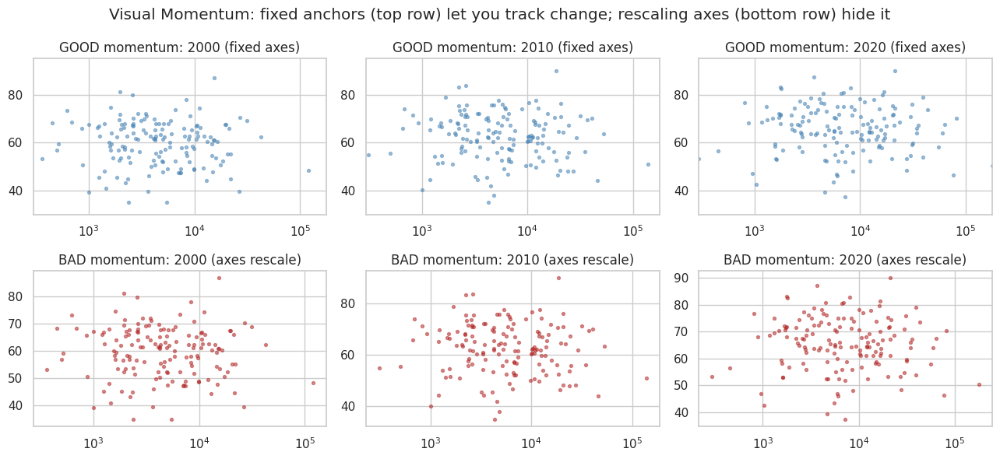

In the bottom row every frame LOOKS similarly spread out even though the underlying data shifted --
because matplotlib silently rescaled each axis to fit that frame alone. Fixed axes (top row) let
you correctly see the rightward/upward drift of the whole cloud over time.


In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for i, y in enumerate([2000, 2010, 2020]):
    snap = df[df.year == y]
    # GOOD momentum: fixed axis limits across all three frames
    axes[0, i].scatter(snap.gdp_per_capita, snap.life_expectancy, s=8, c="steelblue", alpha=0.5)
    axes[0, i].set_xscale("log")
    axes[0, i].set_xlim(df.gdp_per_capita.min(), df.gdp_per_capita.max())
    axes[0, i].set_ylim(30, 95)
    axes[0, i].set_title(f"GOOD momentum: {y} (fixed axes)")

    # BAD momentum: axes auto-rescale to that frame's own min/max each time
    axes[1, i].scatter(snap.gdp_per_capita, snap.life_expectancy, s=8, c="firebrick", alpha=0.5)
    axes[1, i].set_xscale("log")
    axes[1, i].set_title(f"BAD momentum: {y} (axes rescale)")

fig.suptitle("Visual Momentum: fixed anchors (top row) let you track change; rescaling axes (bottom row) hide it")
plt.tight_layout()
plt.show()
print("In the bottom row every frame LOOKS similarly spread out even though the underlying data shifted --")
print("because matplotlib silently rescaled each axis to fit that frame alone. Fixed axes (top row) let")
print("you correctly see the rightward/upward drift of the whole cloud over time.")



## 16. Network Zooming and Degree-of-Relevance Highlighting  *(TB 2, Sec 12.5 — Slide 26)*

**What:** In dense network diagrams, selecting/hovering a node triggers a bounded breadth-first search
that highlights connected nodes within a small path radius, fading everything else.

**Why:** This bypasses static layout limits — edge crossings stay readable because only a *local*
neighborhood needs to be legible at once.

**Demo:** A synthetic trade-relationship network between countries. Selecting a node highlights its
2-hop neighborhood; everything else fades.


In [ ]:

G = nx.watts_strogatz_graph(40, k=4, p=0.3, seed=1)
labels = {i: f"C_{i}" for i in G.nodes}
pos = nx.spring_layout(G, seed=1)

def highlight_neighborhood(selected_node, radius=2):
    lengths = nx.single_source_shortest_path_length(G, selected_node, cutoff=radius)
    highlighted = set(lengths.keys())

    node_colors = ["crimson" if n == selected_node else ("orange" if n in highlighted else "lightgray")
                   for n in G.nodes]
    node_sizes = [260 if n == selected_node else (140 if n in highlighted else 60) for n in G.nodes]
    edge_colors = ["black" if (u in highlighted and v in highlighted) else "whitesmoke" for u, v in G.edges]

    plt.figure(figsize=(7, 6))
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=1)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, edgecolors="black", linewidths=0.5)
    nx.draw_networkx_labels(G, pos, {n: labels[n] for n in highlighted}, font_size=7)
    plt.title(f"Degree-of-Relevance Highlighting: node {selected_node} selected, "
              f"{len(highlighted)-1} nodes within {radius} hops kept legible; rest faded")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

interact(highlight_neighborhood, selected_node=widgets.IntSlider(0, 0, 39, description="Selected node:"),
         radius=widgets.IntSlider(2, 1, 3, description="Hop radius:"))


interactive(children=(IntSlider(value=0, description='Selected node:', max=39), IntSlider(value=2, description…

<function __main__.highlight_neighborhood(selected_node, radius=2)>


## 17. Table Lens: Making Tabular Data Interactive  *(TB 2, Sec 10.4 — Slide 27)*

**What:** Maps raw spreadsheet rows into columns of mini bar charts — showing global trends and local
detail at once. Sorting by any column dynamically reorganizes rows to reveal correlations.

**Why:** Mapping quantitative values to bar widths leverages pre-attentive shape processing, letting an
analyst scan thousands of rows in seconds — the slide notes it beats parallel-coordinate plots in user
testing for decision-making tasks.

**Demo:** A styled `pandas` table where every numeric column renders as an in-cell bar (classic Table
Lens look), sortable.


In [ ]:

table_lens_df = (
    df_latest[["country", "region", "gdp_per_capita", "life_expectancy", "population"]]
    .sort_values("gdp_per_capita", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

styled = (
    table_lens_df.style
    .bar(subset=["gdp_per_capita"], color="#5DADE2")
    .bar(subset=["life_expectancy"], color="#58D68D")
    .bar(subset=["population"], color="#F5B041")
    .format({"gdp_per_capita": "{:,.0f}", "population": "{:,.0f}"})
    .set_caption("Table Lens: top 15 countries by GDP per capita -- bars show magnitude at a glance, "
                 "row order still readable as text")
)
styled


,country,region,gdp_per_capita,life_expectancy,population
0,Country_138,Asia,"177,928",50.400000,"583,863"
1,Country_027,Asia,"81,205",70.200000,"14,323,101"
2,Country_143,Asia,"76,747",46.300000,"1,112,382"
3,Country_043,Americas,"63,587",67.500000,"6,631,904"
4,Country_075,Europe,"59,774",63.900000,"455,894,980"
5,Country_044,Africa,"55,509",58.000000,"684,662"
6,Country_102,Asia,"43,482",73.600000,"6,381,507"
7,Country_120,Americas,"39,220",54.000000,"878,669"
8,Country_145,Africa,"39,100",79.000000,"18,901,071"
9,Country_073,Americas,"35,594",67.100000,"1,156,922"


In [ ]:

# Row-wise expansion on demand: clicking/selecting one row shows its full time trend without losing the table
def expand_row(country_name):
    sub = df[df.country == country_name]
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(sub.year, sub.gdp_per_capita, marker="o", color="#5DADE2")
    ax.set_title(f"Row expansion for {country_name}: on-demand detail while the table above stays intact")
    plt.tight_layout()
    plt.show()

interact(expand_row, country_name=widgets.Dropdown(options=list(table_lens_df.country), description="Expand row:"))


interactive(children=(Dropdown(description='Expand row:', options=('Country_138', 'Country_027', 'Country_143'…

<function __main__.expand_row(country_name)>


## 18. Visual Monitoring and Analytics Dashboard Patterns  *(TB 2, Sec 12.5 — Slide 28)*

**What:** Operational dashboards show all critical indicators on one screen, no interaction required,
spanning three timescales: long-term filter editing, mid-term analysis, continuous peripheral scanning.
Motion/blinking is reserved for critical alerts since peripheral vision is highly motion-sensitive.

**Why:** A second screen for deep drills keeps operators from losing the primary overview.

**Demo:** A single-screen KPI dashboard (no interaction needed to read it) with one simulated "alert"
indicator that uses color, not subtlety, to draw peripheral attention.


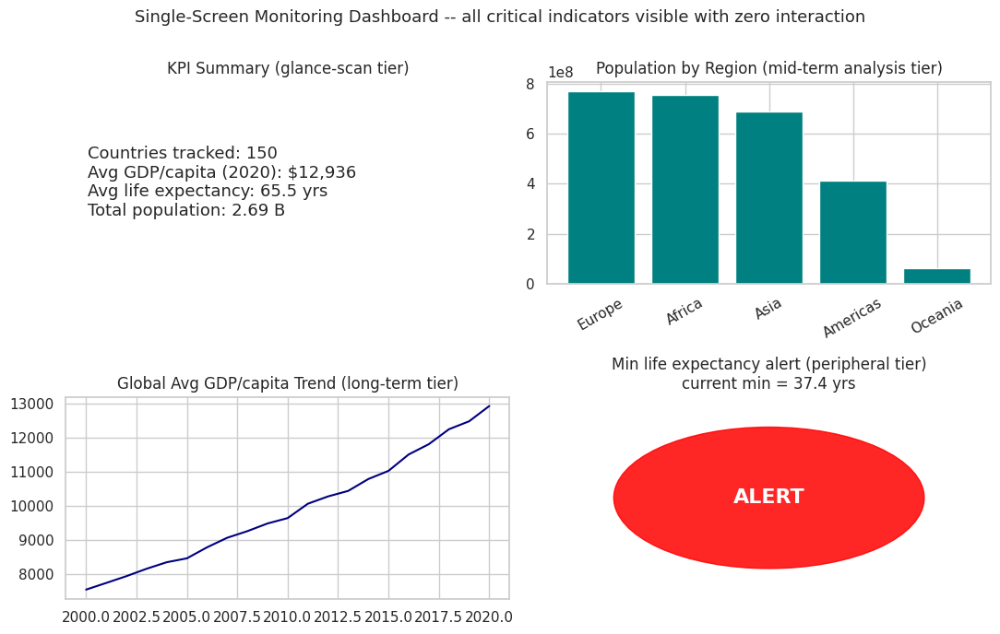

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# Panel 1: KPI big numbers
axes[0,0].axis("off")
kpi_text = (f"Countries tracked: {df_latest.country.nunique()}\n"
            f"Avg GDP/capita (2020): ${df_latest.gdp_per_capita.mean():,.0f}\n"
            f"Avg life expectancy: {df_latest.life_expectancy.mean():.1f} yrs\n"
            f"Total population: {df_latest.population.sum()/1e9:.2f} B")
axes[0,0].text(0.05, 0.5, kpi_text, fontsize=13, va="center")
axes[0,0].set_title("KPI Summary (glance-scan tier)")

# Panel 2: regional distribution (mid-term analysis tier)
region_counts = df_latest.groupby("region").population.sum().sort_values(ascending=False)
axes[0,1].bar(region_counts.index, region_counts.values, color="teal")
axes[0,1].set_title("Population by Region (mid-term analysis tier)")
axes[0,1].tick_params(axis="x", rotation=30)

# Panel 3: trend (long-term filter-editing tier)
trend = df.groupby("year").gdp_per_capita.mean()
axes[1,0].plot(trend.index, trend.values, color="navy")
axes[1,0].set_title("Global Avg GDP/capita Trend (long-term tier)")

# Panel 4: ALERT indicator (continuous peripheral scanning tier) -- uses color, not subtlety
outlier = df_latest.life_expectancy.min()
axes[1,1].axis("off")
alert_color = "red" if outlier < 45 else "green"
axes[1,1].add_patch(mpatches.Circle((0.5, 0.5), 0.35, color=alert_color, alpha=0.85))
axes[1,1].text(0.5, 0.5, "ALERT" if alert_color == "red" else "OK", ha="center", va="center",
               color="white", fontsize=16, weight="bold")
axes[1,1].set_title(f"Min life expectancy alert (peripheral tier)\ncurrent min = {outlier:.1f} yrs")

fig.suptitle("Single-Screen Monitoring Dashboard -- all critical indicators visible with zero interaction", fontsize=13)
plt.tight_layout()
plt.show()



## 19. Model-Based Interactive Planning  *(TB 2, Sec 12.5 — Slide 29)*

**What:** Combines human visual intuition with live simulation: adjusting parameter sliders instantly
re-runs a forecast, with uncertainty bands shown so users don't over-trust the prediction.

**Why:** Transparent model rules let decision-makers verify and debug the projected scenario, and
comparing baseline vs. alternative side-by-side surfaces cause-and-effect.

**Demo:** A GDP growth-rate slider drives a live 15-year projection with a shaded uncertainty band.


In [ ]:

def project_gdp(growth_rate_pct, years_ahead=15):
    base = df_latest.gdp_per_capita.mean()
    yrs = np.arange(0, years_ahead + 1)
    projection = base * (1 + growth_rate_pct/100) ** yrs
    uncertainty = projection * 0.15 * (yrs / years_ahead)  # widening uncertainty band over time

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(2020 + yrs, projection, color="navy", label=f"Projected @ {growth_rate_pct}% growth")
    ax.fill_between(2020 + yrs, projection - uncertainty, projection + uncertainty,
                     color="navy", alpha=0.15, label="Uncertainty band")
    baseline = base * (1 + 0.025) ** yrs  # historical baseline for comparison
    ax.plot(2020 + yrs, baseline, color="gray", ls="--", label="Baseline (2.5% historical avg)")
    ax.set_xlabel("Year"); ax.set_ylabel("Avg GDP per Capita (USD)")
    ax.set_title("Model-Based Planning: adjust the slider to compare scenarios against the baseline")
    ax.legend()
    plt.tight_layout()
    plt.show()

interact(project_gdp, growth_rate_pct=widgets.FloatSlider(2.5, min=-2, max=8, step=0.5, description="Growth %/yr:"))


interactive(children=(FloatSlider(value=2.5, description='Growth %/yr:', max=8.0, min=-2.0, step=0.5), IntSlid…

<function __main__.project_gdp(growth_rate_pct, years_ahead=15)>


## 20. Cognitive Bottlenecks: Working Memory & Change Blindness  *(TB 2, Sec 11.2 — Slide 30)*

**What:** Visual working memory holds only ~3-5 elements at once. **Change blindness**: if a
transition isn't animated/highlighted, the brain often misses even large changes because its internal
scene memory is so simplified.

**Why:** This is why *smooth, animated* transitions (not instant jump-cuts) matter, and why static
side-by-side comparison can beat a zooming interface once 5+ objects are being compared.

**Demo:** Two "snapshots" of the same dashboard — spot the difference **without** an animated
transition (change blindness in action), then the same change **with** it highlighted.


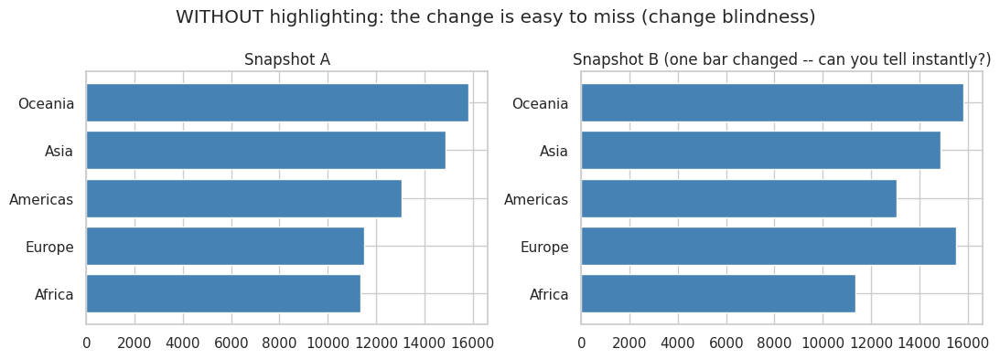

In [ ]:

before = df_latest.groupby("region").gdp_per_capita.mean().sort_values()
after = before.copy()
after["Europe"] *= 1.35  # simulate one region silently changing

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].barh(before.index, before.values, color="steelblue")
axes[0].set_title("Snapshot A")
axes[1].barh(after.index, after.values, color="steelblue")
axes[1].set_title("Snapshot B (one bar changed -- can you tell instantly?)")
fig.suptitle("WITHOUT highlighting: the change is easy to miss (change blindness)")
plt.tight_layout()
plt.show()


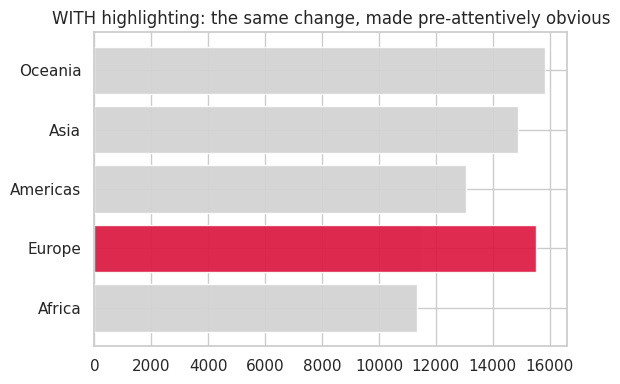

Design implication: never rely on a viewer 'noticing' a change on their own -- animate the
transition or explicitly highlight the delta, or the change may simply not register.


In [ ]:

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["crimson" if r == "Europe" else "lightgray" for r in before.index]
ax.barh(before.index, before.values, color="lightgray", alpha=0.4, label="Before")
ax.barh(after.index, after.values, color=colors, alpha=0.9, label="After")
ax.set_title("WITH highlighting: the same change, made pre-attentively obvious")
plt.tight_layout()
plt.show()
print("Design implication: never rely on a viewer 'noticing' a change on their own -- animate the")
print("transition or explicitly highlight the delta, or the change may simply not register.")



## Summary: Technique -> When to Use It

| Technique | Solves | Use it when... |
|---|---|---|
| Interactive over static | Fixed single-story limit | Audience wants to self-serve explore complex/large data |
| Dynamic queries (sliders) | Finding structure in numeric noise | Filtering large multi-attribute tabular/point data |
| Coordinated views + brushing | Working-memory overload across charts | Same entities need to be tracked across several visual encodings |
| Table Lens | Reading thousands of rows | Sortable, quantitative spreadsheet-like data |
| Geometric fisheye | Focus+context in one canvas | Hierarchies/graphs where a separate detail window is too costly |
| Rapid (semantic) zoom | Focus+context without landmark shift | Maps, large canvases, Google-Earth-like exploration |
| Magic lens | Revealing a hidden layer locally | Overlaying one extra variable onto a spatial base layer |
| Network + degree-of-relevance | Dense graph illegibility | Graphs/networks with high node degree |
| Fitts' Law + lag budgeting | Slow/error-prone selection | Any UI with clickable targets, especially small ones |
| Drill-down cost tiers | Losing analytic flow | Any detail-on-demand interaction — always pick the cheapest tier |
| Animated/highlighted transitions | Change blindness | Any dashboard where a value updates over time |

**This notebook is a teaching demo.** The companion **Activity notebook** asks you to apply a subset of
these techniques to a new, realistic retail-sales dataset — with far more of the coding left to you.
